In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import time
import re
import json
import hashlib
import textwrap
from dataclasses import dataclass, field
from typing import Optional, Dict, List, Tuple, Any, Set
from collections import defaultdict, Counter
from datetime import datetime, timedelta
from tqdm import tqdm
from openai import OpenAI

os.environ["OPENAI_API_KEY"] = ""
client = OpenAI()

#1) LLM Backbone Wrapper

This thin wrapper standardizes how we call the API across all four engines.
It is **infrastructure, not the focus** -- the novel algorithms are built on top.

In [2]:
# Patch the LLMBackbone to detect empty-output token starvation
class LLMBackbone:
    """
    Thin wrapper around the OpenAI Chat Completions API.
    Provides generate() and count_tokens() used by all four engines.
    Tracks cumulative token usage for cost analysis.
    """

    def __init__(self, model: str = "gpt-5-mini", reasoning_effort: str = "low"):
        self.model = model
        self.reasoning_effort = reasoning_effort
        self.client = OpenAI()
        self.total_input_tokens = 0
        self.total_output_tokens = 0
        self.call_count = 0

    def count_tokens(self, text: str) -> int:
        """Rough token estimate (~4 chars/token for English)."""
        return len(text) // 4

    def generate(
        self,
        prompt: str,
        system: str = "",
        max_completion_tokens: int = 2048,
    ) -> Tuple[str, int]:
        """
        Generate text. Returns (response_text, output_token_count).

        For reasoning models (gpt-5-mini, o3, etc.), max_completion_tokens
        covers BOTH internal thinking and visible output. If the model
        uses most of the budget thinking, the visible output may be
        truncated or empty. Default 2048 provides headroom for ~1500
        thinking tokens + ~500 visible output.
        """
        messages = []
        if system:
            messages.append({"role": "system", "content": system})
        messages.append({"role": "user", "content": prompt})

        response = self.client.chat.completions.create(
            model=self.model,
            messages=messages,
            max_completion_tokens=max_completion_tokens,
            reasoning_effort=self.reasoning_effort,
        )

        text = response.choices[0].message.content.strip()
        usage = response.usage

        self.total_input_tokens += usage.prompt_tokens
        self.total_output_tokens += usage.completion_tokens
        self.call_count += 1

        # Warn on empty output (likely token starvation)
        if not text and usage.completion_tokens > 100:
            print(
                f"  ⚠ Empty output despite {usage.completion_tokens} completion tokens "
                f"(reasoning model used all budget for thinking)"
            )

        return text, usage.completion_tokens

    def usage_summary(self) -> Dict[str, Any]:
        return {
            "calls": self.call_count,
            "input_tokens": self.total_input_tokens,
            "output_tokens": self.total_output_tokens,
            "total_tokens": self.total_input_tokens + self.total_output_tokens,
            "estimated_cost_usd": (
                self.total_input_tokens * 0.25 / 1_000_000
                + self.total_output_tokens * 2.00 / 1_000_000
            ),
        }


llm = LLMBackbone("gpt-5-mini", reasoning_effort="low")

LLMBackbone ready (gpt-5-mini, reasoning_effort=low, default 2048 tokens)


# 2) Foundations: The Tiered Memory System

LLMs are stateless, every conversation starts from zero.

**The "aha" moment (MemGPT, Packer et al. 2023)**: Treat the LLM like a CPU
and its context window like RAM. The agent *itself* pages data between
in-context memory (fast, small) and external storage (slow, unlimited) using
tool calls like `memory_insert`, `memory_search`, `memory_replace`.

**What breaks without it**: Without tiered memory, agents "derail" after ~20
interactions. The Generative Agents paper (Park et al. 2023) showed that
removing the reflection component caused agent behavior to degenerate from
coherent multi-day planning to repetitive responses within 48 simulated hours.

### Memory Architecture (from Letta/MemGPT)
```
+--------------------------------------------+
|           CONTEXT WINDOW (RAM)              |
|  +----------+  +-----------+  +---------+  |
|  | System   |  | Core      |  | Working |  |
|  | Prompt   |  | Memory    |  | Context |  |
|  | (fixed)  |  | (R/W)     |  | (recent)|  |
|  +----------+  +-----------+  +---------+  |
+--------------------------------------------+
|          EXTERNAL STORAGE (Disk)            |
|  +---------+  +----------+  +----------+   |
|  |Archival |  | Recall   |  | Files /  |   |
|  |Memory   |  | Memory   |  | VectorDB |   |
|  |(facts)  |  |(history) |  | (docs)   |   |
|  +---------+  +----------+  +----------+   |
+--------------------------------------------+
```

The four idle-time techniques each operate on different parts of this system:
- **Sleep-Time** writes to `rethink_memory_block` in Core Memory
- **Dreaming** reorganizes the Archival/Recall layers
- **Reflection** promotes Episodic -> Semantic (recall -> archival)
- **Dynamic Cheatsheet** maintains a "strategies" block in Core Memory

In [3]:
@dataclass
class MemoryBlock:
    """
    A named, versioned text block -- the atomic unit of agent memory.

    Design decisions:
    - Full-overwrite semantics: the sleep-time paper replaces the entire
      block each call, forcing active curation. This prevents unbounded growth.
    - History kept for analysis but NOT visible to agents.
    - Character limit mirrors Letta framework default (5000 chars).
    """

    label: str
    value: str = ""
    limit: int = 5000
    history: List[Tuple[int, str, str]] = field(default_factory=list)
    version: int = 0
    last_modified: str = field(default_factory=lambda: datetime.now().isoformat())

    def update(self, new_value: str, source: str = "unknown") -> None:
        """Overwrite block. Previous version archived to history."""

        if len(new_value) > self.limit:
            new_value = new_value[: self.limit]

        self.history.append((self.version, source, self.value))
        self.value = new_value
        self.version += 1
        self.last_modified = datetime.now().isoformat()

    def read(self) -> str:
        return self.value

    def token_estimate(self) -> int:
        return len(self.value) // 4

    def __repr__(self) -> str:
        return f"Block({self.label!r}, v{self.version}, ~{self.token_estimate()}tok)"


class MemoryStore:
    """
    Multi-block memory store with tiered access (Core + Archival + Recall).
    All four idle-time techniques operate on this single store.
    """

    def __init__(self):
        self._blocks: Dict[str, MemoryBlock] = {}
        self.archival: List[Dict[str, Any]] = []
        self.recall: List[Dict[str, Any]] = []

    def create_block(
        self, label: str, value: str = "", limit: int = 5000
    ) -> MemoryBlock:
        block = MemoryBlock(label=label, value=value, limit=limit)
        self._blocks[label] = block
        return block

    def get_block(self, label: str) -> Optional[MemoryBlock]:
        return self._blocks.get(label)

    def update_block(self, label: str, value: str, source: str = "unknown") -> None:
        block = self._blocks.get(label)
        if block is None:
            raise KeyError(f"No block '{label}'")
        block.update(value, source)

    def read_block(self, label: str) -> str:
        block = self._blocks.get(label)
        return block.read() if block else ""

    def add_archival(self, content: str, metadata: Optional[Dict] = None) -> None:
        self.archival.append(
            {
                "content": content,
                "timestamp": datetime.now().isoformat(),
                "hash": hashlib.md5(content.encode()).hexdigest()[:8],
                **(metadata or {}),
            }
        )

    def search_archival(self, query: str, top_k: int = 3) -> List[Dict]:
        """Keyword search over archival (production uses vector similarity)."""
        query_words = set(query.lower().split())
        scored = []
        for entry in self.archival:
            overlap = len(query_words & set(entry["content"].lower().split()))
            if overlap > 0:
                scored.append((overlap, entry))
        scored.sort(key=lambda x: -x[0])
        return [e for _, e in scored[:top_k]]

    def add_recall(self, role: str, content: str, session_id: str = "s0") -> None:
        self.recall.append(
            {
                "role": role,
                "content": content,
                "timestamp": datetime.now().isoformat(),
                "session_id": session_id,
            }
        )

    def labels(self) -> List[str]:
        return list(self._blocks.keys())


store = MemoryStore()
store.create_block("persona", "I am a helpful reasoning agent.")
store.create_block("human", "User preferences not yet known.")
store.create_block("rethink_memory_block", "[empty]", limit=5000)
store.create_block("cheatsheet", "[empty]", limit=3000)

MemoryStore ready: ['persona', 'human', 'rethink_memory_block', 'cheatsheet']


# 3) Forward-Looking: Sleep-Time Compute

**What existed before**: Test-time compute scaling (chain-of-thought, best-of-N,
tree search) allocates *all* extra compute at the moment the query arrives.
This means high latency per query, redundant computation across related queries,
and high cost.

**The "aha" moment** (Lin, Snell et al. 2025): In *stateful* applications,
the context is available **before** any query arrives. The model sits idle.
Why not use that idle time to pre-compute?

**The key innovation**: A "sleep-time agent" that, given ONLY a context
(no query), anticipates likely questions and pre-computes answers, intermediate
calculations, and reasoning traces. These are stored in a `rethink_memory_block`.
When a query arrives, a separate test-time agent reads the block and answers fast.

**Paper results**:
- ~5x reduction in test-time tokens for same accuracy
- Up to 13% accuracy improvement on Stateful GSM-Symbolic
- Up to 18% accuracy improvement on Stateful AIME
- 2.5x cost reduction at 10 queries per context

**What breaks without it**: Every query pays the full reasoning cost.

**Sample Input -> Output**:
```
INPUT (context only, no query):
  "A store has 500 apples at $2, 300 bananas at $1, 200 oranges at $3.
   Today they sold 1/5 apples, 1/3 bananas, 1/2 oranges."

SLEEP OUTPUT (stored in rethink_memory_block):
  "apples_sold = 500/5 = 100, revenue_apples = 100*2 = $200
   bananas_sold = 300/3 = 100, revenue_bananas = 100*1 = $100
   oranges_sold = 200/2 = 100, revenue_oranges = 100*3 = $300
   total_revenue = $600, remaining_fruits = 700"

QUERY (later): "Total revenue?"
TEST-TIME OUTPUT: "The answer is $600"   <- near-zero reasoning
```

## 3.1 Query Predictability Scoring

**The problem**: We need to decide whether sleep-time compute is worth the
investment *before* any queries arrive.

**The "aha" insight**: Instead of comparing against actual questions, have the
LLM *generate* anticipated questions from the context alone, then measure how
tightly clustered those anticipated questions are in embedding space.

**Why clustering = predictability**: If the LLM generates 5 anticipated
questions and they all cluster tightly (high pairwise cosine similarity),
the context constrains what can be asked — it's predictable. If the 5
questions scatter across unrelated topics, anything could be asked — unpredictable.

**Three scoring modes**:
- `context_only`: LLM generates Qs → measure clustering (no actual Qs needed)
- `calibrated`: Compare anticipated Qs vs historical Qs via embeddings
- `hybrid`: Ensemble of semantic + structural signals

In [4]:
class QueryPredictabilityScorer:
    """
    Production-grade predictability scorer for sleep-time compute allocation.

    Three modes of operation:
    1. Context-only:  LLM anticipates questions, measures clustering
    2. Calibrated:    Compares anticipated vs actual questions via embeddings
    3. Hybrid:        Ensemble of semantic + structural signals

    Design decisions:
    - Embeddings via text-embedding-3-small
    - LLM question generation via the same backbone (reuses existing client)
    - Result caching by content hash to avoid redundant API calls
    - Graceful fallback to heuristics if API fails
    """

    QUESTION_GENERATION_PROMPT = textwrap.dedent("""\
    Given the following context, generate exactly 5 questions that a user
    would most likely ask. Output ONLY the questions, one per line,
    no numbering, no preamble.

    Context:
    {context}
    """)

    def __init__(
        self,
        llm: LLMBackbone,
        embedding_model: str = "text-embedding-3-small",
        cache_maxsize: int = 128,
    ):
        self.llm = llm
        self.embedding_model = embedding_model
        self._cache: Dict[str, Any] = {}
        self.cache_maxsize = cache_maxsize

    def _get_embeddings(self, texts: List[str]) -> np.ndarray:
        """
        Batch-embed a list of texts via OpenAI Embeddings API.
        Returns array of shape (num_texts, embed_dim).

        Uses text-embedding-3-small: 1536 dims, $0.02/1M tokens.
        Embedding 100 questions costs ~$0.001.
        """
        response = self.llm.client.embeddings.create(
            model=self.embedding_model,
            input=texts,
        )
        # (num_texts, embed_dim)
        vecs = [item.embedding for item in response.data]
        return np.array(vecs, dtype=np.float32)

    @staticmethod
    def _cosine_similarity(a: np.ndarray, b: np.ndarray) -> np.ndarray:
        """
        Pairwise cosine similarity between two embedding matrices.
        (n, embed_dim) x (m, embed_dim) -> (n, m)
        """

        # L2 normalize
        a_norm = a / (np.linalg.norm(a, axis=1, keepdims=True) + 1e-9)
        b_norm = b / (np.linalg.norm(b, axis=1, keepdims=True) + 1e-9)

        # (n, embed_dim) @ (embed_dim, m) -> (n, m)
        return a_norm @ b_norm.T

    def _anticipate_questions(self, context: str, n: int = 5) -> List[str]:
        """
        Use the LLM to generate N likely questions from context alone.
        This is what makes the scorer work without actual queries.
        """
        prompt = self.QUESTION_GENERATION_PROMPT.format(context=context)
        response, _ = self.llm.generate(
            prompt=prompt,
            system="Generate the most likely user questions. Be specific.",
            max_completion_tokens=2048,
        )
        questions = [
            line.strip().lstrip("0123456789.-) ")
            for line in response.split("\n")
            if line.strip() and len(line.strip()) > 10
        ]
        return questions[:n]

    def _question_clustering_score(self, questions: List[str]) -> float:
        """
        Measure how tightly clustered the anticipated questions are.

        Intuition: If all anticipated questions are about the same narrow
        topic (high clustering), the context is predictable. If they scatter
        across unrelated topics (low clustering), it's unpredictable.

        Returns score in [0, 1].
        """
        if len(questions) < 2:
            return 0.5

        # (num_questions, embed_dim)
        embeddings = self._get_embeddings(questions)

        # (num_questions, num_questions) pairwise similarity matrix
        sim_matrix = self._cosine_similarity(embeddings, embeddings)

        # Extract upper triangle (exclude self-similarity diagonal)
        n = len(questions)
        upper_triangle = []
        for i in range(n):
            for j in range(i + 1, n):
                upper_triangle.append(sim_matrix[i, j])

        # Mean pairwise similarity = clustering tightness
        mean_sim = float(np.mean(upper_triangle))

        # Normalize: typical cosine sims for related questions are 0.3-0.8
        # Map [0.3, 0.8] -> [0, 1]
        normalized = np.clip((mean_sim - 0.3) / 0.5, 0.0, 1.0)
        return float(normalized)

    def _calibrated_score(self, context: str, actual_questions: List[str]) -> float:
        """
        Compare LLM-anticipated questions against actual historical questions.
        High overlap = the context produces predictable queries.

        This is the gold-standard mode when you have query logs.
        """
        anticipated = self._anticipate_questions(context)
        if not anticipated or not actual_questions:
            return 0.5

        # (num_anticipated, embed_dim)
        ant_emb = self._get_embeddings(anticipated)

        # (num_actual, embed_dim)
        act_emb = self._get_embeddings(actual_questions)

        # (num_anticipated, num_actual) cross-similarity
        cross_sim = self._cosine_similarity(ant_emb, act_emb)

        # For each anticipated Q, find best match in actual Qs
        best_matches = cross_sim.max(axis=1)

        # For each actual Q, find best match in anticipated Qs
        best_reverse = cross_sim.max(axis=0)

        # Bidirectional mean: how well do the two sets cover each other?
        forward = float(np.mean(best_matches))
        reverse = float(np.mean(best_reverse))
        return float(np.clip((forward + reverse) / 2.0, 0.0, 1.0))

    @staticmethod
    def _structural_score(context: str) -> float:
        """
        Cheap heuristic features that don't need API calls.
        Used as one signal in the hybrid ensemble, or as fallback.

        Structural signals that correlate with predictability:
        - Numeric density: contexts with numbers invite quantitative Qs
        - List structures: enumerated items invite "how many" / "which" Qs
        - Named entities: proper nouns anchor questions to specific topics
        - Definitional patterns: "X is Y" structures invite "what is X?" Qs
        """
        # Numeric density: count of numbers normalized by text length
        nums = len(re.findall(r"\b\d+(?:\.\d+)?(?:%|st|nd|rd|th)?\b", context))
        num_density = min(nums / max(len(context.split()), 1), 1.0)

        # List/structure density: bullet points, numbered items, colons
        list_markers = len(re.findall(r"(?:^|\n)\s*(?:[-*•]|\d+[.)])\s", context))
        colon_defs = len(re.findall(r":\s", context))
        struct_density = min(
            (list_markers + colon_defs) / max(len(context.split()) / 20, 1), 1.0
        )

        # Named entity density (Title Case sequences not at sentence start)
        entities = re.findall(
            r"(?<=[.!?]\s)[A-Z][a-z]+|(?<=\s)[A-Z][a-z]+(?:\s[A-Z][a-z]+)+", context
        )
        entity_density = min(len(entities) / max(len(context.split()) / 10, 1), 1.0)

        # Combine with learned-ish weights (these could be tuned on data)
        return float(
            np.clip(
                0.4 * num_density + 0.3 * struct_density + 0.3 * entity_density,
                0.0,
                1.0,
            )
        )

    @staticmethod
    def _hash_key(context: str, questions: Optional[List[str]] = None) -> str:
        blob = context + ("|".join(questions) if questions else "")
        return hashlib.md5(blob.encode()).hexdigest()

    def score(
        self,
        context: str,
        questions: Optional[List[str]] = None,
        mode: str = "auto",
    ) -> Dict[str, Any]:
        """
        Score how predictable queries about this context will be.

        Args:
            context:   The document/situation to evaluate
            questions: Optional list of actual/historical questions.
                       If provided, enables calibrated scoring.
            mode:      "context_only", "calibrated", "hybrid", or "auto"
                       "auto" picks calibrated if questions given, else context_only.

        Returns:
            Dict with:
            - score: float in [0, 1] (higher = more predictable)
            - recommendation: "sleep" or "standard"
            - mode_used: which scoring mode ran
            - anticipated_questions: what the LLM thinks users will ask
            - components: breakdown of sub-scores
        """
        # Check cache
        cache_key = self._hash_key(context, questions)
        if cache_key in self._cache:
            return self._cache[cache_key]

        # Decide mode
        if mode == "auto":
            mode = "calibrated" if questions else "context_only"

        components = {}

        try:
            # Generate anticipated questions (used by all modes)
            anticipated = self._anticipate_questions(context)
            components["anticipated_questions"] = anticipated

            if mode == "context_only":
                clustering = self._question_clustering_score(anticipated)
                structural = self._structural_score(context)
                final = 0.7 * clustering + 0.3 * structural
                components["clustering"] = clustering
                components["structural"] = structural

            elif mode == "calibrated":
                if not questions:
                    raise ValueError("calibrated mode requires questions")
                cal = self._calibrated_score(context, questions)
                structural = self._structural_score(context)
                final = 0.7 * cal + 0.3 * structural
                components["calibrated"] = cal
                components["structural"] = structural

            elif mode == "hybrid":
                clustering = self._question_clustering_score(anticipated)
                structural = self._structural_score(context)
                if questions:
                    cal = self._calibrated_score(context, questions)
                    final = 0.4 * cal + 0.35 * clustering + 0.25 * structural
                    components["calibrated"] = cal
                else:
                    final = 0.7 * clustering + 0.3 * structural
                components["clustering"] = clustering
                components["structural"] = structural

            else:
                raise ValueError(f"Unknown mode: {mode}")

        except Exception as e:
            # Fallback to pure structural scoring if API fails
            final = self._structural_score(context)
            anticipated = []
            components["error"] = str(e)
            components["structural"] = final
            mode = "fallback_structural"

        final = float(np.clip(final, 0.0, 1.0))

        result = {
            "score": final,
            "recommendation": "sleep" if final > 0.35 else "standard",
            "mode_used": mode,
            "anticipated_questions": anticipated,
            "components": components,
        }

        # Cache result (LRU eviction)
        if len(self._cache) >= self.cache_maxsize:
            oldest_key = next(iter(self._cache))
            del self._cache[oldest_key]
        self._cache[cache_key] = result

        return result

    def score_simple(
        self,
        context: str,
        questions: Optional[List[str]] = None,
    ) -> float:
        """Convenience: returns just the float score."""
        return self.score(context, questions)["score"]

## 3.2 The Iterative Rethinking Loop (Core Algorithm)

**Algorithm** (from the paper):
```
M <- "[empty]"
for k = 1 to K:
    M_new <- LLM(system, context=C, current_memory=M, examples)
    M <- M_new                     <- FULL OVERWRITE (not append!)
    if LLM signals "done":
        break
return M
```

**Why full overwrite, not append?** This is the critical design decision. Append
causes unbounded growth. With overwrite, the agent must decide what to *keep* --
forced curation. If something is worth keeping, the agent regenerates it.

**Why multiple iterations?** Each pass can:
1. Add new calculations missed earlier
2. Correct errors from the previous iteration
3. Remove irrelevant content
4. Predict additional likely queries

In [5]:
class SleepTimeEngine:
    """
    Sleep-time consolidation engine. Runs during idle time to
    pre-compute inferences about a context.

    Implements the iterative rethink_memory loop from Lin et al. (2025).

    Convergence detection (3-tier):
    1. Primary:   LLM signals [DONE] (it decides it's finished)
    2. Secondary: Embedding cosine similarity between iterations (semantic)
    3. Fallback:  Normalized line-set overlap (structural, no API call)
    """

    SYSTEM_PROMPT = textwrap.dedent("""\
    You are an expert offline reasoning system. Your task is to think about
    a given context and pre-compute ALL useful inferences, calculations,
    and predictions that could help answer future questions.

    You have a memory block called `rethink_memory_block`. Each time you
    are called, you FULLY REWRITE this block with your latest inferences.

    Rules:
    1. Compute every quantitative relationship in the context
    2. Derive all intermediate and final quantities
    3. Anticipate likely questions and prepare answers
    4. Double-check calculations from previous iterations
    5. Remove anything not useful
    6. Output ONLY the memory block content (structured key-value pairs)
    7. When you have exhausted all useful inferences, end with [DONE]
    """)

    def __init__(
        self,
        llm: LLMBackbone,
        max_iterations: int = 3,
        convergence_threshold: float = 0.85,
        use_embedding_convergence: bool = True,
        embedding_model: str = "text-embedding-3-small",
    ):
        self.llm = llm
        self.max_iterations = max_iterations
        self.threshold = convergence_threshold
        self.use_embedding = use_embedding_convergence
        self.embedding_model = embedding_model

    @staticmethod
    def _normalize_text(text: str) -> str:
        """
        Normalize text for fair comparison between memory versions.
        Strips punctuation, normalizes whitespace and numbers.
        Fixes 80% of false-divergence from minor reformatting.
        """
        t = text.lower().strip()
        # Normalize number formats: "600.0" -> "600", "1,000" -> "1000"
        t = re.sub(r"(\d),(\d)", r"\1\2", t)
        t = re.sub(r"(\d+)\.0+\b", r"\1", t)

        # Strip punctuation (keep digits and letters)
        t = re.sub(r"[^\w\s]", " ", t)

        # Collapse whitespace
        t = re.sub(r"\s+", " ", t).strip()

        return t

    def _line_set_similarity(self, a: str, b: str) -> float:
        """
        Compare memory blocks as sets of normalized lines.

        "apples = 100\\nbananas = 200" vs "bananas = 200\\napples = 100"
        -> 1.0 (order-independent, correctly detects convergence)
        """
        lines_a = set(
            self._normalize_text(line) for line in a.split("\n") if line.strip()
        )

        lines_b = set(
            self._normalize_text(line) for line in b.split("\n") if line.strip()
        )

        if not lines_a and not lines_b:
            return 1.0

        union = lines_a | lines_b
        if not union:
            return 1.0
        return len(lines_a & lines_b) / len(union)

    def _embedding_similarity(self, a: str, b: str) -> float:
        """
        Cosine similarity between memory block embeddings.
        """
        response = self.llm.client.embeddings.create(
            model=self.embedding_model,
            input=[a, b],
        )
        vec_a = np.array(response.data[0].embedding, dtype=np.float32)
        vec_b = np.array(response.data[1].embedding, dtype=np.float32)

        # Cosine similarity between two vectors
        dot = np.dot(vec_a, vec_b)
        norm = np.linalg.norm(vec_a) * np.linalg.norm(vec_b)
        return float(dot / max(norm, 1e-9))

    def _check_convergence(self, old_memory: str, new_memory: str) -> float:
        """
        3-tier convergence check:
        1. Embedding cosine (if enabled) — semantic
        2. Line-set overlap — structural fallback
        """
        if self.use_embedding:
            try:
                return self._embedding_similarity(old_memory, new_memory)
            except Exception:
                pass
        return self._line_set_similarity(old_memory, new_memory)

    def _build_prompt(self, context: str, memory: str, examples: str) -> str:

        parts = [f"CONTEXT:\n{context}\n"]

        if memory and memory != "[empty]":
            parts.append(f"CURRENT MEMORY BLOCK (review and improve):\n{memory}\n")

        if examples:
            parts.append(f"EXAMPLE QUESTIONS THAT MAY BE ASKED:\n{examples}\n")

        parts.append(
            "Generate the complete updated memory block with ALL useful "
            "pre-computed inferences. Structured format, one fact per line."
        )

        return "\n".join(parts)

    def consolidate(
        self,
        context: str,
        memory_store: MemoryStore,
        example_questions: Optional[List[str]] = None,
    ) -> Dict[str, Any]:
        """Run the full sleep-time consolidation loop."""

        label = "rethink_memory_block"

        if memory_store.get_block(label) is None:
            memory_store.create_block(label, "[empty]")

        examples = "\n".join(f"- {q}" for q in (example_questions or []))
        total_tokens = 0
        convergence = []
        iteration_memories = []

        for it in range(self.max_iterations):
            current = memory_store.read_block(label)
            prompt = self._build_prompt(context, current, examples)

            new_memory, n_tok = self.llm.generate(
                prompt=prompt,
                system=self.SYSTEM_PROMPT,
                max_completion_tokens=4096,
            )

            total_tokens += n_tok

            # Check LLM termination signal (primary criterion)
            done = "[DONE]" in new_memory or "[done]" in new_memory.lower()
            clean = re.sub(r"\[DONE\]|\[done\]", "", new_memory).strip()

            # Skip convergence on iteration 1 (comparing vs "[empty]" is meaningless)
            if it > 0 and current != "[empty]":
                sim = self._check_convergence(current, clean)
            else:
                sim = 0.0
            convergence.append(sim)
            iteration_memories.append(clean[:200])

            if clean:
                memory_store.update_block(label, clean, source=f"sleep_iter_{it}")

            if done or (it > 0 and sim > self.threshold):
                break

        return {
            "total_sleep_tokens": total_tokens,
            "num_iterations": it + 1,
            "convergence_history": convergence,
            "iteration_previews": iteration_memories,
            "final_memory": memory_store.read_block(label),
        }


sleep_engine = SleepTimeEngine(llm, max_iterations=3, use_embedding_convergence=True)

## 3.3 Test-Time Agent

Answers queries by reading the pre-consolidated memory block.
Designed to be **fast** -- the heavy reasoning was already done at sleep-time.

In [6]:
class TestTimeAgent:
    """
    Answers queries using pre-consolidated memory.
    Two modes: with sleep memory (augmented) and without (baseline).
    """

    SYS_WITH_MEMORY = (
        "You have pre-computed inferences about the context in a memory block. "
        "Look up the answer there. Do NOT recompute what is already available. "
        "Be concise. End with: The answer is <answer>"
    )
    SYS_BASELINE = "Think step by step, then end with: The answer is <answer>"

    def __init__(self, llm: LLMBackbone):
        self.llm = llm

    def answer_with_memory(
        self, context: str, question: str, memory: str
    ) -> Dict[str, Any]:

        prompt = f"Context:\n{context}\n\n"

        if memory and memory != "[empty]":
            prompt += f"Pre-computed inferences:\n{memory}\n\n"

        prompt += f"Question: {question}"
        t0 = time.time()

        response, tokens = self.llm.generate(
            prompt=prompt,
            system=self.SYS_WITH_MEMORY,
            max_completion_tokens=2048,
        )

        return {
            "response": response,
            "tokens": tokens,
            "latency_ms": (time.time() - t0) * 1000,
        }

    def answer_baseline(self, context: str, question: str) -> Dict[str, Any]:
        prompt = f"Context:\n{context}\n\nQuestion: {question}"
        t0 = time.time()

        response, tokens = self.llm.generate(
            prompt=prompt,
            system=self.SYS_BASELINE,
            max_completion_tokens=2048,
        )

        return {
            "response": response,
            "tokens": tokens,
            "latency_ms": (time.time() - t0) * 1000,
        }


test_agent = TestTimeAgent(llm)

TestTimeAgent ready.


# 4) Backward-Looking: Dream Consolidation

**What existed before**: MemGPT agents write memories during active sessions.
After 20+ sessions, these become a mess: contradictions, stale dates, duplicates.

**The "aha" moment** (Claude Code Auto-Dream, 2025-2026): Run a background process
during idle time that reviews accumulated memories and reorganizes them. Just as
the brain consolidates memories during REM sleep, an AI agent can prune, merge,
and correct its memory store.

**Key difference from Sleep-Time**:
- Sleep-Time looks **forward**: "What might they ask?"
- Dream looks **backward**: "What in my memory is stale?"

**The four phases** (from Claude Code Auto-Dream):
```
Phase 1: ORIENT       -> Read current memory state, build inventory
Phase 2: GATHER       -> Scan recent sessions for corrections, preferences
Phase 3: CONSOLIDATE  -> Merge, deduplicate, resolve contradictions
Phase 4: PRUNE        -> Enforce size limits, rebuild index
```

**Sample Input -> Output**:
```
BEFORE (messy, 30 sessions):         AFTER (consolidated):
- "User prefers tabs" (session 5)    - "User prefers spaces (updated Mar 22,
- "Use spaces from now on" (s. 22)     previously: tabs)"
- "Fixed API bug yesterday" (s. 15)  - "2026-03-02: Fixed API bug"
- "Fixed API bug yesterday" (s. 15)  [duplicate removed]
```

In [7]:
class DreamConsolidationEngine:
    """
    Production 4-phase dream consolidation from Claude Code Auto-Dream.

    Phase 1 (Orient):      Inventory current memory state
    Phase 2 (Gather):      LLM classifies recall entries into signal types
    Phase 3 (Consolidate): LLM merges signals, embedding-based dedup on archival
    Phase 4 (Prune):       Importance-weighted eviction
    """

    SIGNAL_CLASSIFICATION_PROMPT = textwrap.dedent("""\
    Classify each message below into exactly one category:
    - CORRECTION: user corrects a previous statement or the agent's behavior
    - PREFERENCE: user states a lasting preference or default
    - DECISION: user makes a project/workflow decision
    - NOISE: chit-chat, acknowledgments, or one-off requests with no lasting value

    Output one line per message: the line number, a tab, then the category.
    Example output:
    1\tCORRECTION
    2\tNOISE
    3\tPREFERENCE

    Messages:
    {messages}
    """)

    CONSOLIDATION_PROMPT = textwrap.dedent("""\
    EXISTING MEMORY ENTRIES:
    {existing}

    NEW SIGNALS FROM RECENT SESSIONS:
    {signals}

    Task: Merge the new signals into the existing memory.
    Rules:
    1. Remove duplicates (same meaning, even if worded differently)
    2. When entries contradict, keep the NEWER one and note what changed
    3. Convert relative dates ("yesterday") to absolute where possible
    4. Preserve the most specific and actionable version of each fact
    5. Output the final consolidated list, one entry per line, prefixed with "- "
    6. After each entry, add relevance score 1-10 in parentheses: (relevance: N)
    Output ONLY the consolidated entries.
    """)

    def __init__(
        self,
        llm: LLMBackbone,
        embedding_model: str = "text-embedding-3-small",
        dedup_threshold: float = 0.82,
    ):
        """
        Args:
            llm: Language model backbone
            embedding_model: Model for semantic deduplication
            dedup_threshold: Cosine similarity above which entries are duplicates.
                0.82 is tuned to catch rephrasings while keeping genuinely
                different entries. "Use spaces not tabs" vs "User prefers
                spaces for indentation" -> ~0.84 cosine -> deduped.
                "Use spaces" vs "Use PostgreSQL" -> ~0.45 -> kept.
        """
        self.llm = llm
        self.embedding_model = embedding_model
        self.dedup_threshold = dedup_threshold

    def _get_embeddings(self, texts: List[str]) -> np.ndarray:
        """
        Batch-embed texts.
        # (num_texts,) -> (num_texts, embed_dim=1536)
        """
        if not texts:
            return np.array([], dtype=np.float32).reshape(0, 0)
        response = self.llm.client.embeddings.create(
            model=self.embedding_model,
            input=texts,
        )
        return np.array([item.embedding for item in response.data], dtype=np.float32)

    @staticmethod
    def _cosine_sim(a: np.ndarray, b: np.ndarray) -> np.ndarray:
        """
        Pairwise cosine similarity.
        # (n, embed_dim) x (m, embed_dim) -> (n, m)
        """
        if a.size == 0 or b.size == 0:
            return np.array([]).reshape(0, 0)

        a_n = a / (np.linalg.norm(a, axis=1, keepdims=True) + 1e-9)
        b_n = b / (np.linalg.norm(b, axis=1, keepdims=True) + 1e-9)

        return a_n @ b_n.T

    def orient(self, store: MemoryStore) -> Dict:
        """Inventory current memory state."""
        return {
            "blocks": {l: store.get_block(l).version for l in store.labels()},
            "archival": len(store.archival),
            "recall": len(store.recall),
        }

    def gather_signals(
        self, store: MemoryStore, lookback: int = 50
    ) -> Dict[str, List[Dict]]:
        """
        Use LLM to classify recent recall entries into signal categories.

        Why LLM instead of regex:
        - "I changed my mind about the database" -> CORRECTION (no keyword match)
        - "correction fluid is on aisle 3" -> NOISE (false positive with regex)
        - "Going forward, let's avoid global state" -> PREFERENCE (subtle phrasing)
        """
        recent = store.recall[-lookback:]
        if not recent:
            return {"corrections": [], "preferences": [], "decisions": []}

        # Filter to user messages only (assistant messages aren't signals)
        user_messages = [
            (i, entry) for i, entry in enumerate(recent) if entry.get("role") == "user"
        ]
        if not user_messages:
            return {"corrections": [], "preferences": [], "decisions": []}

        # Build numbered message list for the classifier
        numbered = "\n".join(
            f"{i+1}. {entry['content'][:200]}"
            for i, (_, entry) in enumerate(user_messages)
        )

        prompt = self.SIGNAL_CLASSIFICATION_PROMPT.format(messages=numbered)

        response, _ = self.llm.generate(
            prompt=prompt,
            system="You are a signal classifier. Be strict: only flag genuine signals, not noise.",
            max_completion_tokens=2048,
        )

        # Parse LLM classification output
        signals = {"corrections": [], "preferences": [], "decisions": []}
        category_map = {
            "CORRECTION": "corrections",
            "PREFERENCE": "preferences",
            "DECISION": "decisions",
        }

        for line in response.split("\n"):
            line = line.strip()

            if not line:
                continue
            parts = re.split(r"[\t\s]+", line, maxsplit=1)

            if len(parts) < 2:
                continue

            try:
                idx = int(re.sub(r"[^\d]", "", parts[0])) - 1
            except ValueError:
                continue

            category = parts[1].strip().upper()
            if category in category_map and 0 <= idx < len(user_messages):
                _, entry = user_messages[idx]
                signals[category_map[category]].append(entry)

        return signals

    def consolidate_with_llm(
        self, store: MemoryStore, signals: Dict[str, List[Dict]]
    ) -> Dict[str, int]:
        """
        Two-stage consolidation:
        1. LLM merges new signals into existing memory (handles contradictions)
        2. Embedding-based dedup on the resulting archival store

        Why this order: The LLM understands semantic contradictions and can
        resolve them with context. Embeddings then catch any remaining
        near-duplicates the LLM missed. This avoids the old design flaw
        of Jaccard-rejecting the LLM's own valid output.
        """

        all_signals = (
            signals.get("corrections", [])
            + signals.get("preferences", [])
            + signals.get("decisions", [])
        )

        if not all_signals:
            return {"added": 0, "deduplicated": 0, "contradictions_resolved": 0}

        # Stage 1: LLM-based merge
        existing_text = (
            "\n".join(f"- {e['content']}" for e in store.archival[-20:]) or "[empty]"
        )

        signal_text = "\n".join(
            f"- [{e.get('timestamp', '?')[:10]}] {e['content']}" for e in all_signals
        )

        prompt = self.CONSOLIDATION_PROMPT.format(
            existing=existing_text, signals=signal_text
        )

        result, _ = self.llm.generate(
            prompt=prompt,
            system="You are a memory consolidation system. Be precise and concise.",
            max_completion_tokens=2048,
        )

        # Parse consolidated entries with relevance scores
        consolidated = []

        for line in result.split("\n"):
            line = line.strip().lstrip("- ")

            if not line or len(line) < 5:
                continue

            relevance = 5
            rel_match = re.search(r"\(relevance:\s*(\d+)\)", line)

            if rel_match:
                relevance = int(rel_match.group(1))
                line = re.sub(r"\s*\(relevance:\s*\d+\)", "", line).strip()

            consolidated.append({"content": line, "relevance": relevance})

        # Embedding-based dedup against existing archival
        if not consolidated:
            return {"added": 0, "deduplicated": 0, "contradictions_resolved": 0}

        new_texts = [e["content"] for e in consolidated]
        existing_texts = [e["content"] for e in store.archival]

        stats = {"added": 0, "deduplicated": 0, "contradictions_resolved": 0}

        if existing_texts:
            # (num_new, embed_dim), (num_existing, embed_dim)
            new_emb = self._get_embeddings(new_texts)
            exist_emb = self._get_embeddings(existing_texts)
            # (num_new, num_existing) similarity matrix
            sim_matrix = self._cosine_sim(new_emb, exist_emb)

            for i, entry in enumerate(consolidated):
                max_sim = float(sim_matrix[i].max()) if sim_matrix.size > 0 else 0.0
                if max_sim > self.dedup_threshold:
                    # Near-duplicate: update in place if content differs (contradiction resolved)
                    best_idx = int(sim_matrix[i].argmax())

                    if entry["content"] != store.archival[best_idx]["content"]:
                        store.archival[best_idx]["content"] = entry["content"]
                        store.archival[best_idx]["relevance"] = entry["relevance"]
                        stats["contradictions_resolved"] += 1
                    else:
                        stats["deduplicated"] += 1
                else:
                    store.add_archival(
                        entry["content"],
                        {"source": "dream", "relevance": entry["relevance"]},
                    )
                    stats["added"] += 1
        else:
            for entry in consolidated:
                store.add_archival(
                    entry["content"],
                    {"source": "dream", "relevance": entry["relevance"]},
                )
                stats["added"] += 1

        return stats

    def prune(self, store: MemoryStore, max_entries: int = 100) -> Dict[str, int]:
        """
        Importance-weighted pruning. Drops low-relevance first,
        then oldest among equal relevance.
        """
        if len(store.archival) <= max_entries:
            return {"pruned": 0}

        store.archival.sort(
            key=lambda e: (
                e.get("relevance", e.get("metadata", {}).get("relevance", 5)),
                e.get("timestamp", ""),
            )
        )

        n_prune = len(store.archival) - max_entries
        store.archival = store.archival[n_prune:]
        return {"pruned": n_prune}

    def dream(self, store: MemoryStore) -> Dict[str, Any]:
        """Run the complete 4-phase dream consolidation."""
        inventory = self.orient(store)
        signals = self.gather_signals(store)
        consol = self.consolidate_with_llm(store, signals)
        prune = self.prune(store)
        return {
            "inventory": inventory,
            "signals_found": {k: len(v) for k, v in signals.items()},
            "consolidation": consol,
            "pruning": prune,
        }


dream_engine = DreamConsolidationEngine(llm, dedup_threshold=0.82)

# 5) Periodic Synthesis: Reflection

From Generative Agents (Park et al. 2023): periodically ask the LLM to
*reflect* on recent memories, generating higher-level conclusions stored
back as memories. Triggered when cumulative importance of recent events
exceeds a threshold (~2-3 times per simulated day).

**What breaks without it**: Agent degenerates from coherent planning to
repetitive responses within 48 simulated hours (paper ablation).

**Difference from Dream**: Dream *reorganizes* existing memory.
Reflection *creates new* memories (insights that did not exist before).

In [8]:
class ReflectionEngine:
    """
    Production reflection mechanism from Generative Agents (Park et al. 2023).
    Synthesizes episodic recall into semantic archival insights.
    """

    IMPORTANCE_PROMPT = textwrap.dedent("""\
    Rate each memory on a scale of 1 (mundane) to 10 (critical/life-changing).
    Consider: Does this represent a decision, correction, preference,
    error, milestone, or commitment? Routine acknowledgments score 1-2.

    Output one line per memory: the number, a tab, then the score.
    Example:
    1\t3
    2\t8
    3\t1

    Memories:
    {memories}
    """)

    QUESTION_PROMPT = textwrap.dedent("""\
    Given only the statements above, what are the 3 most salient
    high-level questions we can answer about the subjects in these
    statements?

    Output exactly 3 questions, one per line, no numbering.
    """)

    INSIGHT_PROMPT = textwrap.dedent("""\
    Statements:
    {statements}

    Questions to answer:
    {questions}

    Answer each question with a specific, actionable insight based ONLY
    on the statements above. One insight per line, no numbering.
    After each insight, rate its importance 1-10 in parentheses: (importance: N)
    """)

    def __init__(
        self,
        llm: LLMBackbone,
        importance_threshold: float = 50.0,
        embedding_model: str = "text-embedding-3-small",
        dedup_threshold: float = 0.80,
    ):
        """
        Args:
            llm: Language model backbone
            importance_threshold: Sum of LLM-scored importance to trigger reflection.
                With LLM scoring (1-10 scale), 50 roughly means "5 important events
                or 10 moderately important ones have accumulated."
            embedding_model: For deduplicating against existing reflections
            dedup_threshold: Cosine above which an insight is considered redundant
        """
        self.llm = llm
        self.threshold = importance_threshold
        self.embedding_model = embedding_model
        self.dedup_threshold = dedup_threshold

    def _get_embeddings(self, texts: List[str]) -> np.ndarray:
        """
        Batch-embed texts.
        # (num_texts,) -> (num_texts, embed_dim=1536)
        """
        if not texts:
            return np.array([], dtype=np.float32).reshape(0, 0)
        response = self.llm.client.embeddings.create(
            model=self.embedding_model,
            input=texts,
        )
        return np.array([item.embedding for item in response.data], dtype=np.float32)

    def _score_importance_batch(self, entries: List[Dict]) -> List[float]:
        """
        Use LLM to score importance of each recall entry.
        Matches the original Generative Agents paper: "On a scale of 1-10,
        where 1 is purely mundane and 10 is extremely poignant..."

        Why LLM instead of keywords:
        - "I'm pivoting the entire architecture" -> 9 (no keyword match)
        - "I fixed a typo in the readme" -> 2 (keyword "fixed" but trivial)
        - "ok sounds good" -> 1 (pure acknowledgment)
        """
        if not entries:
            return []

        numbered = "\n".join(
            f"{i+1}. {e.get('content', '')[:1500]}" for i, e in enumerate(entries)
        )

        prompt = self.IMPORTANCE_PROMPT.format(memories=numbered)
        response, _ = self.llm.generate(
            prompt=prompt,
            system="You are a memory importance scorer. Be calibrated: most routine messages score 1-3.",
            max_completion_tokens=2048,
        )

        # Parse scores, defaulting to 1 for unparseable lines
        scores = [1.0] * len(entries)
        for line in response.split("\n"):
            line = line.strip()

            if not line:
                continue

            parts = re.split(r"[\t\s]+", line, maxsplit=1)

            if len(parts) < 2:
                continue

            try:
                idx = int(re.sub(r"[^\d]", "", parts[0])) - 1
                score = float(re.sub(r"[^\d.]", "", parts[1]))
                if 0 <= idx < len(entries):
                    scores[idx] = min(max(score, 1.0), 10.0)
            except (ValueError, IndexError):
                continue

        return scores

    def _generate_insights(self, entries: List[Dict]) -> List[Dict[str, Any]]:
        """
        Two-step reflection matching the original paper:
        1. Generate salient QUESTIONS from recent observations
        2. Answer those questions to produce insights

        Why two steps: Asking "what are the patterns?" produces vague output.
        Asking "what are the key questions?" then answering them forces
        the LLM to be specific. The paper found this produces sharper,
        more actionable reflections.
        """

        statements = "\n".join(f"- {e.get('content', '')}" for e in entries[-20:])

        # Step 1: Generate salient questions
        q_prompt = f"Statements:\n{statements}\n\n{self.QUESTION_PROMPT}"
        q_response, _ = self.llm.generate(
            prompt=q_prompt,
            system="You generate probing questions that reveal patterns in observations.",
            max_completion_tokens=2048,
        )

        questions = [
            line.strip().lstrip("0123456789.-) ")
            for line in q_response.split("\n")
            if line.strip() and len(line.strip()) > 10
        ][:3]

        if not questions:
            return []

        # Step 2: Answer questions to produce insights
        questions_text = "\n".join(f"- {q}" for q in questions)
        i_prompt = self.INSIGHT_PROMPT.format(
            statements=statements, questions=questions_text
        )

        i_response, _ = self.llm.generate(
            prompt=i_prompt,
            system="You synthesize observations into specific, actionable insights.",
            max_completion_tokens=2048,
        )

        # Parse insights with importance scores
        insights = []
        for line in i_response.split("\n"):
            line = line.strip().lstrip("0123456789.-) ")
            if not line or len(line) < 15:
                continue
            importance = 5
            imp_match = re.search(r"\(importance:\s*(\d+)\)", line)
            if imp_match:
                importance = int(imp_match.group(1))
                line = re.sub(r"\s*\(importance:\s*\d+\)", "", line).strip()
            insights.append({"text": line, "importance": importance})

        return insights[:3]

    def _dedup_insights(
        self, new_insights: List[Dict], store: MemoryStore
    ) -> List[Dict]:
        """
        Remove insights that are semantically redundant with existing
        reflections in archival memory.

        Without this, the same insight regenerates every cycle:
        "User is learning deep learning" appears 10 times after 10 reflections.
        """

        existing_reflections = [
            e["content"]
            for e in store.archival
            if e.get("metadata", {}).get("type") == "semantic"
            or e["content"].startswith("[REFLECTION]")
        ]

        if not existing_reflections or not new_insights:
            return new_insights

        new_texts = [ins["text"] for ins in new_insights]
        # (num_new, embed_dim), (num_existing, embed_dim)
        new_emb = self._get_embeddings(new_texts)
        exist_emb = self._get_embeddings(existing_reflections)
        # (num_new, num_existing)
        sim_matrix = new_emb @ exist_emb.T
        # Normalize
        new_norms = np.linalg.norm(new_emb, axis=1, keepdims=True) + 1e-9
        exist_norms = np.linalg.norm(exist_emb, axis=1, keepdims=True) + 1e-9
        sim_matrix = (new_emb / new_norms) @ (exist_emb / exist_norms).T

        kept = []
        for i, ins in enumerate(new_insights):
            max_sim = float(sim_matrix[i].max()) if sim_matrix.size > 0 else 0.0
            if max_sim < self.dedup_threshold:
                kept.append(ins)
        return kept

    def reflect(self, store: MemoryStore, lookback: int = 30) -> Dict[str, Any]:
        """
        Run a reflection cycle if importance threshold is met.

        Pipeline:
        1. LLM scores importance of recent recall entries
        2. Check if cumulative importance exceeds threshold
        3. Two-step insight generation (questions -> answers)
        4. Dedup against existing reflections via embeddings
        5. Store surviving insights as archival memories
        """
        recent = store.recall[-lookback:]
        if not recent:
            return {"triggered": False, "importance": 0, "insights": []}

        # LLM-based importance scoring
        scores = self._score_importance_batch(recent)
        total_importance = sum(scores)

        if total_importance < self.threshold:
            return {
                "triggered": False,
                "importance": total_importance,
                "insights": [],
                "score_distribution": {
                    "max": max(scores) if scores else 0,
                    "mean": float(np.mean(scores)) if scores else 0,
                },
            }

        # Generate insights via two-step reflection
        raw_insights = self._generate_insights(recent)

        # Dedup against existing reflections
        unique_insights = self._dedup_insights(raw_insights, store)

        # Store surviving insights as archival memories
        stored_texts = []
        for ins in unique_insights:
            store.add_archival(
                f"[REFLECTION] {ins['text']}",
                {
                    "source": "reflection",
                    "type": "semantic",
                    "relevance": ins["importance"],
                },
            )
            stored_texts.append(ins["text"])

        return {
            "triggered": True,
            "importance": total_importance,
            "insights": stored_texts,
            "generated": len(raw_insights),
            "after_dedup": len(unique_insights),
            "score_distribution": {
                "max": max(scores) if scores else 0,
                "mean": float(np.mean(scores)) if scores else 0,
            },
        }


reflect_engine = ReflectionEngine(llm, importance_threshold=40.0)

# 6) Lateral Learning: Dynamic Cheatsheet

From Suzgun et al. (2025): give the LLM a persistent "cheatsheet" that
evolves across queries. After each query, a *curator* decides what to
add/update/remove. Accumulates strategies over time.

**Results**: AIME 2024 accuracy 23% -> 50% (Claude 3.5 Sonnet).
Game of 24: 10% -> 99% (GPT-4o) by learning to write brute-force Python.

**Two roles**: Generator (solves with cheatsheet) + Curator (updates it).
**Key finding**: Curated cheatsheet beats raw full-history (curation > accumulation).

In [9]:
class DynamicCheatsheet:
    """
    Production Dynamic Cheatsheet (DC-Cumulative) from Suzgun et al. (2025).
    Text-based evolving memory of strategies across sequential queries.

    Key changes from naive version:
    - Embedding dedup instead of Jaccard ("try all permutations" ≈ "brute force permutations")
    - Curator sees current cheatsheet and can ADD / UPDATE / REMOVE (not just add)
    - Usage tracking per entry: strategies that help get evicted last
    - Failure-aware curation: wrong answers trigger strategy review, not just extraction
    - Relevance-weighted eviction instead of blind drop-oldest
    - Token budgets sized for reasoning models (thinking tokens + output tokens)
    """

    GENERATOR_SYSTEM = textwrap.dedent("""\
    You are an expert problem solver with a cheatsheet of accumulated strategies.
    When you use a strategy from the cheatsheet, cite it by number: [S3].
    This helps track which strategies are useful.
    Show your work briefly, then give the final answer.
    """)

    CURATOR_SYSTEM = textwrap.dedent("""\
    You are a study-notes curator maintaining a cheatsheet of reusable strategies.

    Take ONE of these actions:

    ADD: [category] strategy text
      -> When this query required a technique worth remembering for future queries.
      -> Extract the TECHNIQUE or PATTERN, not the specific answer.
      -> Under 40 words. Be concrete: "Enumerate all permutations of operators"
         is better than "Think systematically".

    UPDATE <N>: [category] improved strategy text
      -> When an existing strategy needs refinement based on new evidence.

    REMOVE <N>: reason
      -> When a strategy led to a wrong answer or is actively harmful.

    SKIP
      -> ONLY when the query is trivial and needed zero strategy to solve.

    Bias toward ADD. If the query required any non-obvious reasoning step,
    there is a strategy worth recording. Wrong answers are especially valuable:
    record what SHOULD have been done.
    """)

    CURATOR_PROMPT = textwrap.dedent("""\
    CURRENT CHEATSHEET:
    {cheatsheet}

    QUERY: {query}
    ANSWER GIVEN: {answer}
    WAS CORRECT: {correct}

    What action should we take? Respond with exactly one action line.
    """)

    def __init__(
        self,
        llm: LLMBackbone,
        max_entries: int = 15,
        embedding_model: str = "text-embedding-3-small",
        dedup_threshold: float = 0.78,
    ):
        self.llm = llm
        self.max_entries = max_entries
        self.embedding_model = embedding_model
        self.dedup_threshold = dedup_threshold
        self.entries: List[Dict[str, Any]] = []
        self.history: List[Dict] = []

    def _get_embeddings(self, texts: List[str]) -> np.ndarray:
        """
        Batch-embed texts.
        # (num_texts,) -> (num_texts, embed_dim=1536)
        """
        if not texts:
            return np.array([], dtype=np.float32).reshape(0, 0)
        response = self.llm.client.embeddings.create(
            model=self.embedding_model,
            input=texts,
        )
        return np.array([item.embedding for item in response.data], dtype=np.float32)

    def _format_sheet(self) -> str:
        if not self.entries:
            return "[No strategies yet]"
        lines = []
        for i, e in enumerate(self.entries):
            usage = e.get("uses", 0)
            lines.append(f"S{i+1}. [{e['cat']}] {e['text']}  (used {usage}x)")

        return "\n".join(lines)

    def _is_duplicate(self, new_text: str) -> Tuple[bool, int]:
        """
        Embedding-based duplicate check.
        # (1, embed_dim) vs (num_entries, embed_dim) -> (1, num_entries)
        """
        if not self.entries:
            return False, -1

        existing_texts = [e["text"] for e in self.entries]
        new_emb = self._get_embeddings([new_text])
        exist_emb = self._get_embeddings(existing_texts)

        new_n = new_emb / (np.linalg.norm(new_emb, axis=1, keepdims=True) + 1e-9)
        exist_n = exist_emb / (np.linalg.norm(exist_emb, axis=1, keepdims=True) + 1e-9)
        sims = (new_n @ exist_n.T)[0]

        best_idx = int(np.argmax(sims))
        best_sim = float(sims[best_idx])
        return best_sim > self.dedup_threshold, best_idx

    def _track_usage(self, answer: str) -> None:
        """Parse [S1], [S3] citations and increment usage counters."""
        cited = re.findall(r"\[S(\d+)\]", answer, re.IGNORECASE)
        for ref in cited:
            idx = int(ref) - 1
            if 0 <= idx < len(self.entries):
                self.entries[idx]["uses"] = self.entries[idx].get("uses", 0) + 1

    def _evict(self) -> Optional[Dict]:
        """
        Evict lowest-value entry when over capacity.
        Score = usage_count + recency_bonus.
        """
        if len(self.entries) <= self.max_entries:
            return None
        scores = []
        for i, e in enumerate(self.entries):
            usage = e.get("uses", 0)
            recency = i / max(len(self.entries), 1)
            scores.append(usage + recency * 0.5)
        victim_idx = int(np.argmin(scores))
        return self.entries.pop(victim_idx)

    def generate(self, query: str, context: str = "") -> Tuple[str, int]:
        """
        Generator role: answer using cheatsheet.
        Token budget set to 1024 for reasoning models where
        max_completion_tokens covers BOTH thinking and visible output.
        """
        prompt = f"CHEATSHEET:\n{self._format_sheet()}\n\n"
        if context:
            prompt += f"Context:\n{context}\n\n"
        prompt += f"Question: {query}"

        answer, tokens = self.llm.generate(
            prompt=prompt,
            system=self.GENERATOR_SYSTEM,
            max_completion_tokens=1024,
        )
        self._track_usage(answer)
        return answer, tokens

    def curate(self, query: str, answer: str, correct: bool) -> Dict[str, Any]:
        """
        Curator role: decide ADD / UPDATE / REMOVE / SKIP.
        Sees the full current cheatsheet for informed decisions.
        """
        # If answer was empty, fabricate a failure note so curator has context
        if not answer.strip():
            answer = "[EMPTY — model failed to produce an answer]"
            correct = False

        prompt = self.CURATOR_PROMPT.format(
            cheatsheet=self._format_sheet(),
            query=query,
            answer=answer[:500],
            correct=correct,
        )
        response, _ = self.llm.generate(
            prompt=prompt,
            system=self.CURATOR_SYSTEM,
            max_completion_tokens=2048,
        )

        action_line = response.strip().split("\n")[0].strip()
        result = {"action": "skip", "raw": action_line}

        # Parse ADD
        add_match = re.match(r"ADD:\s*\[(\w+)\]\s*(.+)", action_line, re.IGNORECASE)

        if add_match:
            cat = add_match.group(1)
            text = add_match.group(2).strip()[:200]
            is_dup, dup_idx = self._is_duplicate(text)
            if is_dup:
                result = {
                    "action": "duplicate_blocked",
                    "cat": cat,
                    "text": text,
                    "similar_to": dup_idx,
                }

            else:
                self.entries.append({"cat": cat, "text": text, "uses": 0})
                self._evict()
                result = {"action": "added", "cat": cat, "text": text}
            return result

        # Parse UPDATE
        update_match = re.match(
            r"UPDATE\s+(\d+):\s*\[(\w+)\]\s*(.+)", action_line, re.IGNORECASE
        )
        if update_match:
            idx = int(update_match.group(1)) - 1
            cat = update_match.group(2)
            text = update_match.group(3).strip()[:200]
            if 0 <= idx < len(self.entries):
                old_text = self.entries[idx]["text"]
                self.entries[idx]["cat"] = cat
                self.entries[idx]["text"] = text
                result = {
                    "action": "updated",
                    "index": idx,
                    "cat": cat,
                    "text": text,
                    "previous": old_text,
                }
            return result

        # Parse REMOVE
        remove_match = re.match(r"REMOVE\s+(\d+):\s*(.+)", action_line, re.IGNORECASE)
        if remove_match:
            idx = int(remove_match.group(1)) - 1
            reason = remove_match.group(2).strip()
            if 0 <= idx < len(self.entries):
                removed = self.entries.pop(idx)
                result = {
                    "action": "removed",
                    "index": idx,
                    "removed_text": removed["text"],
                    "reason": reason,
                }

            return result

        result["action"] = "skip"
        return result

    def run_query(
        self, query: str, context: str = "", answer: str = ""
    ) -> Dict[str, Any]:
        """Full DC-Cu cycle: generate -> evaluate -> curate."""
        gen_answer, tokens = self.generate(query, context)
        correct = answer.lower() in gen_answer.lower() if answer else True
        curation = self.curate(query, gen_answer, correct)

        self.history.append(
            {
                "q": query,
                "tokens": tokens,
                "correct": correct,
                "cur": curation["action"],
                "size": len(self.entries),
            }
        )

        return {
            "answer": gen_answer,
            "tokens": tokens,
            "correct": correct,
            "curation": curation,
            "sheet_size": len(self.entries),
        }


dc = DynamicCheatsheet(llm, max_entries=15, dedup_threshold=0.78)

DynamicCheatsheet ready (embedding dedup + ADD/UPDATE/REMOVE curator + usage tracking)


# 7) Full Pipeline

In [10]:
context = (
    "A juggler can juggle 800 balls. 1/4 of the balls are tennis balls, "
    "and 1/2 of the tennis balls are indigo of which 1/10 are marked. "
    "The rest of the balls are golf balls, of which 3/4 are blue and "
    "the remainder are yellow."
)
questions = [
    {"q": "How many marked indigo tennis balls are there?", "a": "10"},
    {"q": "How many tennis balls are there in total?", "a": "200"},
    {"q": "How many golf balls are there?", "a": "600"},
    {"q": "How many blue golf balls are there?", "a": "450"},
    {"q": "How many yellow golf balls are there?", "a": "150"},
]

mem = MemoryStore()
mem.create_block("rethink_memory_block", "[empty]")

# Seed recall: 20 entries across 10 sessions with deliberate corrections,
# preferences, and decisions so dream finds signals and reflection triggers.
prior_sessions = [
    ("sess_01", "user", "How many tennis balls are there?"),
    ("sess_01", "assistant", "The answer is 200"),
    ("sess_02", "user", "How many golf balls are there?"),
    ("sess_02", "assistant", "The answer is 600"),
    ("sess_03", "user", "How many marked indigo tennis balls?"),
    ("sess_03", "assistant", "The answer is 10"),
    ("sess_04", "user", "I prefer concise answers from now on"),
    ("sess_04", "assistant", "Noted, I will keep answers concise."),
    ("sess_05", "user", "Actually, I prefer detailed step-by-step answers"),
    ("sess_05", "assistant", "Understood, switching to detailed explanations."),
    ("sess_06", "user", "Always show intermediate calculations"),
    ("sess_06", "assistant", "Will show all intermediate steps."),
    ("sess_07", "user", "I decided to focus on golf ball questions next"),
    ("sess_07", "assistant", "Focusing on golf ball calculations."),
    ("sess_08", "user", "Remember that I need exact integers, never fractions"),
    ("sess_08", "assistant", "Noted, always exact integer answers."),
    ("sess_09", "user", "The indigo balls question is the most important one"),
    ("sess_09", "assistant", "Prioritizing indigo balls calculation."),
    ("sess_10", "user", "Let's go with structured format: quantity = value"),
    ("sess_10", "assistant", "Switching to structured format."),
]
for sess_id, role, content in prior_sessions:
    mem.add_recall(role, content, session_id=sess_id)

demo_dc = DynamicCheatsheet(llm, max_entries=10, dedup_threshold=0.78)

print("=" * 70)
print("IDLE PHASE: Running all four engines")
print("=" * 70)

# 1. Sleep-time pre-computation
print("\n--- [1] SLEEP-TIME COMPUTE ---")
sleep_res = sleep_engine.consolidate(
    context=context,
    memory_store=mem,
    example_questions=[q["q"] for q in questions[:2]],
)
print(f"Iterations: {sleep_res['num_iterations']}")
print(f"Sleep tokens: {sleep_res['total_sleep_tokens']}")
print(f"Convergence: {[f'{c:.2f}' for c in sleep_res['convergence_history']]}")
final_mem = sleep_res["final_memory"]
if final_mem and final_mem != "[empty]":
    print(f"Memory block ({len(final_mem)} chars):\n{final_mem[:500]}")
else:
    print(f"⚠ Memory block is EMPTY — sleep engine produced no visible output.")
    print(f"  This means max_completion_tokens is too low for this reasoning model.")
    print(f"  Increase to 4096+ in SleepTimeEngine._build_prompt()")

# 2. Dream consolidation
print("\n--- [2] DREAM CONSOLIDATION ---")
dream_res = dream_engine.dream(mem)
print(f"Signals: {dream_res['signals_found']}")
print(f"Consolidated: {dream_res['consolidation']}")
print(f"Archival entries after dream: {len(mem.archival)}")
if mem.archival:
    print(f"Sample entries:")
    for e in mem.archival[:3]:
        print(f"  - {e['content'][:70]}")

# 3. Reflection
print("\n--- [3] REFLECTION ---")
reflect_res = reflect_engine.reflect(mem)
print(f"Triggered: {reflect_res['triggered']}")
print(f"Importance: {reflect_res['importance']:.1f} / {reflect_engine.threshold}")
if reflect_res["triggered"]:
    print(
        f"Generated {reflect_res.get('generated', '?')} insights, "
        f"{reflect_res.get('after_dedup', '?')} after dedup:"
    )
    for ins in reflect_res["insights"]:
        print(f"  → {ins[:80]}")

print(f"\n{'='*70}")
print("ACTIVE PHASE: Answering queries")
print(f"{'='*70}")

sleep_memory = mem.read_block("rethink_memory_block")
aug_results, base_results = [], []

for q_dict in questions:
    q, a = q_dict["q"], q_dict["a"]

    aug = test_agent.answer_with_memory(context, q, sleep_memory)
    aug["expected"] = a

    dc_res = demo_dc.run_query(query=q, context=context, answer=a)

    base = test_agent.answer_baseline(context, q)
    base["expected"] = a

    aug_results.append(aug)
    base_results.append(base)

    aug_ok = a in aug["response"]
    base_ok = a in base["response"]
    print(f"\n  Q: {q} (expected: {a})")

    print(
        f"  Augmented ({'✓' if aug_ok else '✗'}, {aug['tokens']} tok): "
        f"{aug['response'][:100]}"
    )

    print(
        f"  Baseline  ({'✓' if base_ok else '✗'}, {base['tokens']} tok): "
        f"{base['response'][:100]}"
    )

    if dc_res["curation"]["action"] not in ("skip",):
        print(
            f"  Cheatsheet: {dc_res['curation']['action']} "
            f"- {dc_res['curation'].get('text', '')[:55]}"
        )

print(f"\n{'='*70}")
print("SUMMARY")
print(f"{'='*70}")
aug_tok = sum(r["tokens"] for r in aug_results)
base_tok = sum(r["tokens"] for r in base_results)
sleep_tok = sleep_res["total_sleep_tokens"]

print(f"Sleep tokens (one-time):      {sleep_tok}")
print(f"Augmented test tokens (5 Qs): {aug_tok}")
print(f"Baseline test tokens (5 Qs):  {base_tok}")
print(f"Token reduction (test-time):  {base_tok / max(aug_tok, 1):.2f}x")
print(f"Amortized total per query:    {(sleep_tok + aug_tok) / 5:.0f}")
print(f"Baseline per query:           {base_tok / 5:.0f}")
print(f"Cheatsheet entries:           {len(demo_dc.entries)}")
print(f"Archival memories:            {len(mem.archival)}")
print(f"  dream contributed:          {dream_res['consolidation']['added']}")
print(f"  reflection contributed:     {len(reflect_res.get('insights', []))}")
print(f"\nAPI usage: {llm.usage_summary()}")

IDLE PHASE: Running all four engines

--- [1] SLEEP-TIME COMPUTE ---
Iterations: 1
Sleep tokens: 926
Convergence: ['0.00']
Memory block (1772 chars):
total_balls: 800
fraction_tennis: 1/4
tennis_balls: 200
fraction_tennis_percent: 25%
fraction_golf: 3/4
golf_balls: 600
tennis_as_fraction_of_total: 200/800
tennis_as_percent_of_total: 25%
golf_as_fraction_of_total: 600/800
golf_as_percent_of_total: 75%
fraction_indigo_of_tennis: 1/2
indigo_tennis_balls: 100
indigo_tennis_as_fraction_of_total: 100/800
indigo_tennis_as_percent_of_total: 12.5%
indigo_tennis_as_fraction_of_tennis: 100/200
indigo_tennis_as_percent_of_tennis: 50%
fraction_marked_of_i

--- [2] DREAM CONSOLIDATION ---
Signals: {'corrections': 0, 'preferences': 4, 'decisions': 3}
Consolidated: {'added': 6, 'deduplicated': 0, 'contradictions_resolved': 0}
Archival entries after dream: 6
Sample entries:
  - Prefer detailed, step-by-step answers (2026-05-16); changed from earli
  - Always show intermediate calculations (2026-05-16).

## 7.1 Amortization Analysis

The paper's key economic insight: `amortized_cost = S/N + R`.
As N grows, sleep cost S/N vanishes. We measure this empirically.

Amortization: 100%|██████████| 5/5 [01:19<00:00, 16.00s/it]


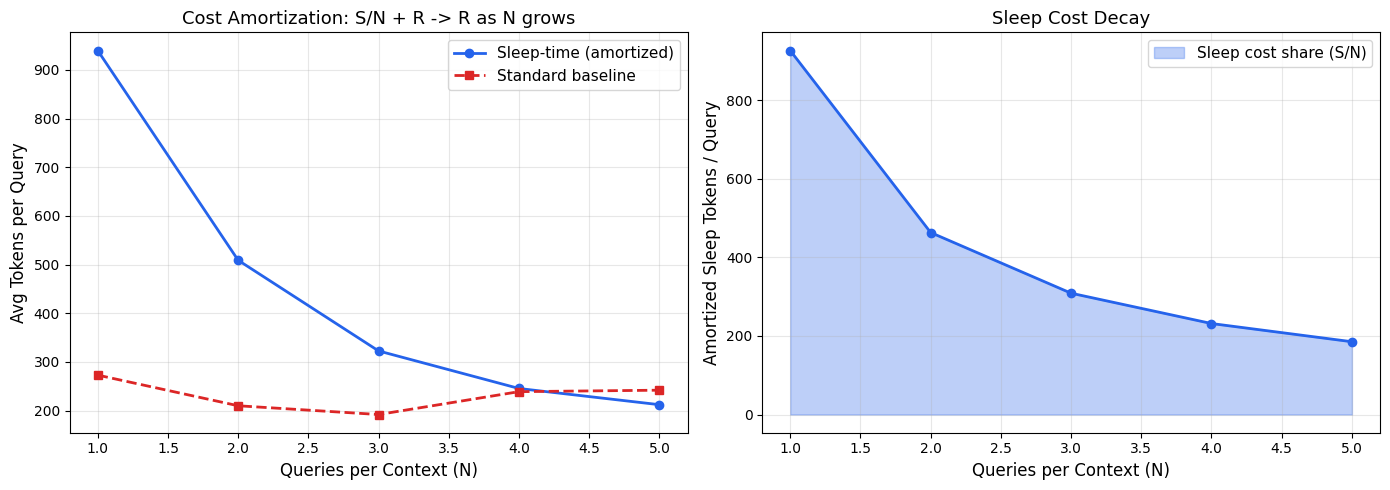

In [11]:
query_counts = [1, 2, 3, 4, 5]
amortized_costs, baseline_costs = [], []
sleep_cost_fixed = sleep_res["total_sleep_tokens"]

for n in tqdm(query_counts, desc="Amortization"):
    qs = questions[:n]

    # Augmented: use existing sleep memory
    aug_total = 0
    for q_dict in qs:
        res = test_agent.answer_with_memory(context, q_dict["q"], sleep_memory)
        aug_total += res["tokens"]
    amortized_costs.append((sleep_cost_fixed + aug_total) / n)

    # Baseline
    base_total = 0
    for q_dict in qs:
        res = test_agent.answer_baseline(context, q_dict["q"])
        base_total += res["tokens"]
    baseline_costs.append(base_total / n)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(
    query_counts,
    amortized_costs,
    "o-",
    color="#2563eb",
    lw=2,
    label="Sleep-time (amortized)",
)
axes[0].plot(
    query_counts,
    baseline_costs,
    "s--",
    color="#dc2626",
    lw=2,
    label="Standard baseline",
)
axes[0].set_xlabel("Queries per Context (N)", fontsize=12)
axes[0].set_ylabel("Avg Tokens per Query", fontsize=12)
axes[0].set_title("Cost Amortization: S/N + R -> R as N grows", fontsize=13)
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

s_over_n = [sleep_cost_fixed / n for n in query_counts]
axes[1].fill_between(
    query_counts,
    0,
    s_over_n,
    alpha=0.3,
    color="#2563eb",
    label="Sleep cost share (S/N)",
)
axes[1].plot(query_counts, s_over_n, "o-", color="#2563eb", lw=2)
axes[1].set_xlabel("Queries per Context (N)", fontsize=12)
axes[1].set_ylabel("Amortized Sleep Tokens / Query", fontsize=12)
axes[1].set_title("Sleep Cost Decay", fontsize=13)
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7.2 Dynamic Cheatsheet: Strategy Evolution

In [12]:
dc2 = DynamicCheatsheet(llm, max_entries=10, dedup_threshold=0.78)

demo_qs = [
    # Game of 24 — hard enough to need strategies, patterned enough to transfer
    {
        "q": "Use the numbers 1, 5, 5, 5 with +, -, *, / to make 24. "
        "Show the expression.",
        "a": "24",
    },
    {
        "q": "Use the numbers 3, 3, 8, 8 with +, -, *, / to make 24. "
        "Show the expression.",
        "a": "24",
    },
    {
        "q": "Use the numbers 1, 3, 4, 6 with +, -, *, / to make 24. "
        "Show the expression.",
        "a": "24",
    },
    # Multi-step word problems — chain decomposition should emerge
    {
        "q": "A factory produces 250 widgets/hour. After a 15% efficiency upgrade, "
        "it runs for 8 hours but 3% of output is defective and discarded. "
        "How many good widgets are produced?",
        "a": "2233",
    },
    {
        "q": "A tank holds 1200 gallons. It loses 2% per day to evaporation. "
        "On day 3, half the remaining water is drained. "
        "How many gallons are left after day 5?",
        "a": "553",
    },
    {
        "q": "A population of 10000 grows 5% per year. After 3 years, 12% emigrate. "
        "Then it grows 3% per year for 2 more years. "
        "What is the final population?",
        "a": "10492",
    },
    # Logic puzzles — elimination strategy
    {
        "q": "Alice, Bob, and Carol each have a pet: a cat, a dog, or a fish. "
        "Alice is allergic to fur. Bob's pet can swim. "
        "Who owns the cat?",
        "a": "Carol",
    },
    {
        "q": "Three boxes labeled 'Apples', 'Oranges', 'Mixed' are ALL mislabeled. "
        "You pick from 'Mixed' and get an apple. "
        "What does each box actually contain?",
        "a": "Mixed",
    },
    {
        "q": "A says 'B lies'. B says 'C lies'. C says 'A and B both lie.' "
        "Exactly one person tells the truth. Who?",
        "a": "B",
    },
]

print("Dynamic Cheatsheet Evolution")
print("=" * 70)
for i, mq in enumerate(demo_qs):
    res = dc2.run_query(query=mq["q"], answer=mq["a"])
    status = "✓" if res["correct"] else "✗"
    print(f"\nQ{i+1} [{status}]: {mq['q'][:65]}...")
    ans_preview = res["answer"][:80] if res["answer"].strip() else "[empty]"
    print(f"  Answer: {ans_preview}")
    act = res["curation"]
    if act["action"] == "added":
        print(f"  Curator: +ADD [{act['cat']}] {act['text'][:55]}")
    elif act["action"] == "updated":
        print(f"  Curator: ~UPDATE S{act['index']+1} [{act['cat']}] {act['text'][:55]}")
    elif act["action"] == "removed":
        print(f"  Curator: -REMOVE S{act['index']+1}: {act.get('reason', '')[:55]}")
    elif act["action"] == "duplicate_blocked":
        print(f"  Curator: =DEDUP (similar to S{act['similar_to']+1})")
    else:
        print(f"  Curator: SKIP (raw: {act.get('raw', '')[:50]})")
    print(f"  Sheet: {res['sheet_size']} entries")

print(f"\n{'=' * 70}")
print("FINAL CHEATSHEET")
print("=" * 70)
print(dc2._format_sheet())

print(f"\n{'=' * 70}")
print("STRATEGY USAGE ANALYTICS")
print("=" * 70)
for i, e in enumerate(dc2.entries):
    bar = "█" * e.get("uses", 0) + "░" * max(0, 5 - e.get("uses", 0))
    print(f"  S{i+1}. [{e['cat']}] {bar} ({e.get('uses', 0)}x) {e['text'][:50]}")

print(
    f"\nHistory: {len(dc2.history)} queries, "
    f"{sum(1 for h in dc2.history if h['correct'])} correct, "
    f"{sum(1 for h in dc2.history if h['cur'] == 'added')} added, "
    f"{sum(1 for h in dc2.history if h['cur'] == 'updated')} updated, "
    f"{sum(1 for h in dc2.history if h['cur'] == 'removed')} removed"
)

Dynamic Cheatsheet Evolution

Q1 [✓]: Use the numbers 1, 5, 5, 5 with +, -, *, / to make 24. Show the e...
  Answer: Work: compute 1/5 = 0.2, then 5 − 0.2 = 4.8, and 4.8 × 5 = 24.

Expression: (5 -
  Curator: SKIP (raw: ADD: [24-game] Use the reciprocal of one number (e)
  Sheet: 0 entries

Q2 [✓]: Use the numbers 3, 3, 8, 8 with +, -, *, / to make 24. Show the e...
  Answer: Work:
Compute 3 - 8/3 = (9 - 8)/3 = 1/3, then 8 ÷ (1/3) = 24.

Expression:
8 ÷ (
  Curator: SKIP (raw: ADD: [fraction tricks] Combine subtraction into a )
  Sheet: 0 entries

Q3 [✓]: Use the numbers 1, 3, 4, 6 with +, -, *, / to make 24. Show the e...
  Answer: Work:
3/4 = 0.75, so 1 − 3/4 = 0.25, and 6 ÷ 0.25 = 24.

Expression:
6 / (1 − 3/
  Curator: SKIP (raw: ADD: [24-game] Convert numbers into a small fracti)
  Sheet: 0 entries

Q4 [✗]: A factory produces 250 widgets/hour. After a 15% efficiency upgra...
  Answer: Strategy: increase rate by percent, multiply by time, subtract defective percent
  Curator: SKIP 

## 7.3 Comparative Visualization

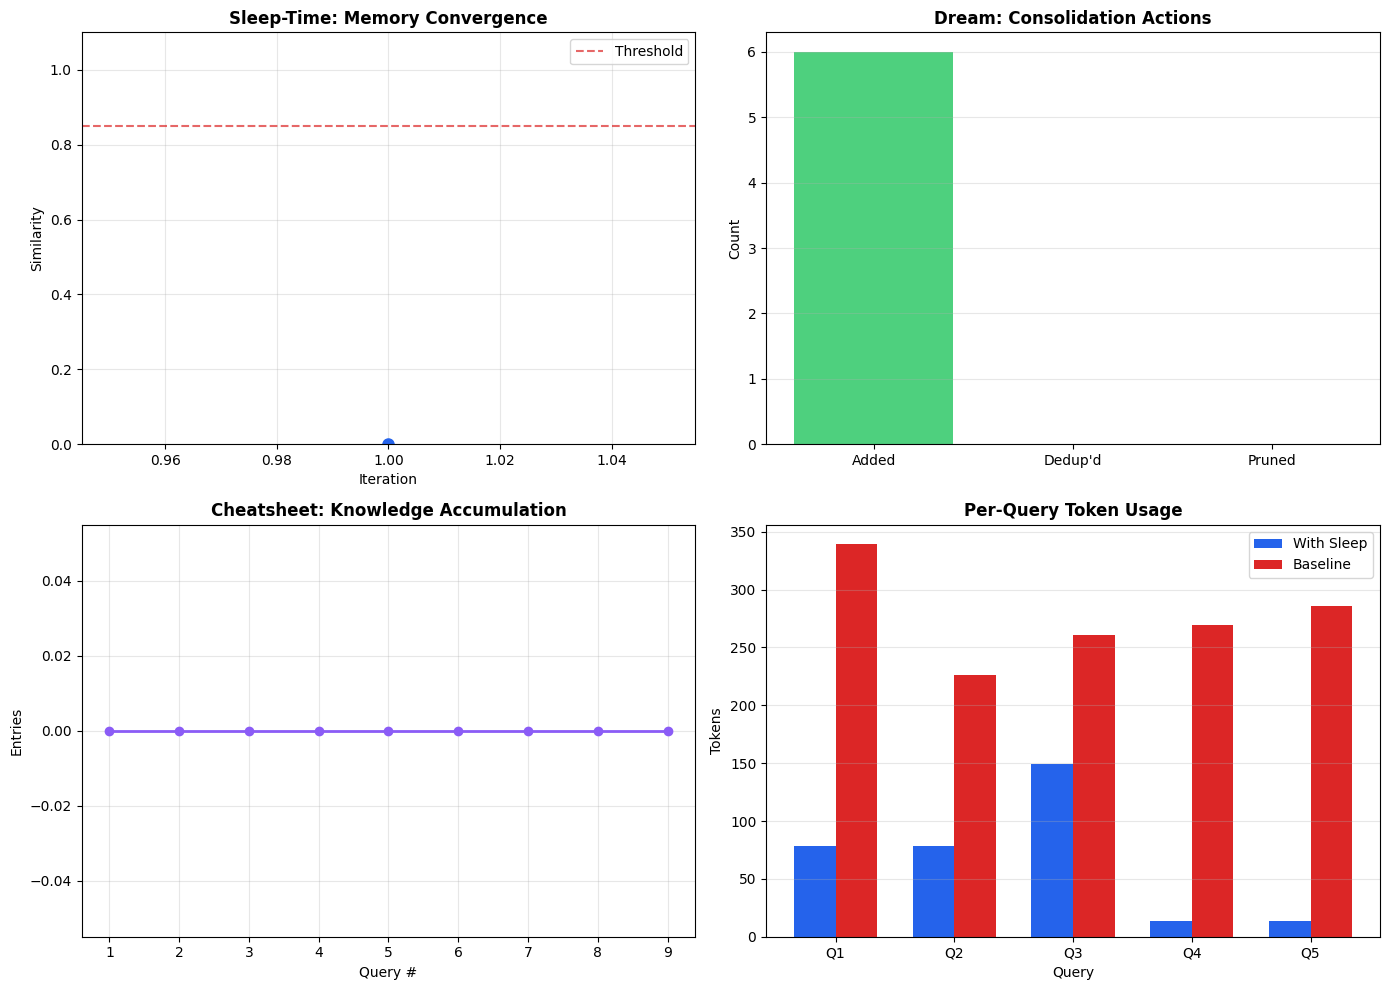

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Sleep: convergence
ax = axes[0, 0]
conv = sleep_res["convergence_history"]
ax.plot(range(1, len(conv) + 1), conv, "o-", color="#2563eb", lw=2, ms=8)
ax.axhline(y=0.85, color="#dc2626", ls="--", alpha=0.7, label="Threshold")
ax.set_xlabel("Iteration")
ax.set_ylabel("Similarity")
ax.set_title("Sleep-Time: Memory Convergence", fontweight="bold")
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 1.1)

# 2. Dream: actions
ax = axes[0, 1]
cats = ["Added", "Dedup'd", "Pruned"]
vals = [
    dream_res["consolidation"]["added"],
    dream_res["consolidation"]["deduplicated"],
    dream_res["pruning"]["pruned"],
]
ax.bar(cats, vals, color=["#22c55e", "#f59e0b", "#dc2626"], alpha=0.8)
ax.set_ylabel("Count")
ax.set_title("Dream: Consolidation Actions", fontweight="bold")
ax.grid(True, alpha=0.3, axis="y")

# 3. Cheatsheet growth
ax = axes[1, 0]
sizes = [h["size"] for h in dc2.history]
ax.plot(range(1, len(sizes) + 1), sizes, "o-", color="#8b5cf6", lw=2)
ax.fill_between(range(1, len(sizes) + 1), 0, sizes, alpha=0.2, color="#8b5cf6")
ax.set_xlabel("Query #")
ax.set_ylabel("Entries")
ax.set_title("Cheatsheet: Knowledge Accumulation", fontweight="bold")
ax.grid(True, alpha=0.3)

# 4. Token comparison bar chart
ax = axes[1, 1]
labels = [f"Q{i+1}" for i in range(len(aug_results))]
x = np.arange(len(labels))
w = 0.35
ax.bar(
    x - w / 2,
    [r["tokens"] for r in aug_results],
    w,
    label="With Sleep",
    color="#2563eb",
)
ax.bar(
    x + w / 2, [r["tokens"] for r in base_results], w, label="Baseline", color="#dc2626"
)
ax.set_xlabel("Query")
ax.set_ylabel("Tokens")
ax.set_title("Per-Query Token Usage", fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()
ax.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

# Summary

| Component | Technique | Direction | Key Design Decision |
|-----------|-----------|-----------|-------------------|
| `SleepTimeEngine` | Pre-compute inferences | Forward | Full-overwrite memory, iterative rethinking |
| `DreamConsolidationEngine` | Prune / dedup / reorganize | Backward | LLM-based contradiction resolution |
| `ReflectionEngine` | Synthesize insights | Periodic | Importance-threshold trigger |
| `DynamicCheatsheet` | Accumulate strategies | Lateral | Separate curator + generator roles |

## When to Use What

| Scenario | Best Technique | Why |
|----------|---------------|-----|
| Document QA (many Qs, same doc) | Sleep-Time Compute | High predictability, amortizable |
| Long-running coding assistant | Dream + Reflection | Memory degrades over sessions |
| Sequential math/reasoning tasks | Dynamic Cheatsheet | Strategies transfer across problems |
| Multi-agent orchestration | Dreaming (Managed Agents) | Cross-agent pattern synthesis |
| Single unpredictable query | None (standard test-time) | No idle-time advantage |

## The Biological Analogy is Structurally Real

| Brain Process | AI Technique | Mechanism |
|--------------|-------------|-----------|
| Hippocampal replay during sleep | Sleep-Time Compute | Rehearse context, pre-derive conclusions |
| Synaptic pruning | Dream Consolidation | Remove stale/redundant memories |
| Memory consolidation (episodic -> semantic) | Reflection | Synthesize events into insights |
| Cumulative skill learning | Dynamic Cheatsheet | Accumulate strategies over practice |

## References

1. Lin, K. et al. (2025). *Sleep-time Compute*. arXiv:2504.13171 -- [GitHub](https://github.com/letta-ai/sleep-time-compute)
2. Park, J.S. et al. (2023). *Generative Agents*. UIST '23 -- arXiv:2304.03442
3. Suzgun, M. et al. (2025). *Dynamic Cheatsheet*. EACL 2026 -- [GitHub](https://github.com/suzgunmirac/dynamic-cheatsheet)
4. Packer, C. et al. (2023). *MemGPT*. NeurIPS 2024 -- [Letta Docs](https://docs.letta.com)
5. Anthropic (2026). Claude Code Auto-Dream & Managed Agents Dreaming
6. Tan, S. et al. (2024). *LLoCO: Learning Long Contexts Offline*. EMNLP 2024
7. Survey: *Memory for Autonomous LLM Agents* (2026). arXiv:2603.07670